# X (formerly Twitter) Sentiment Analysis of U.S. Airlines 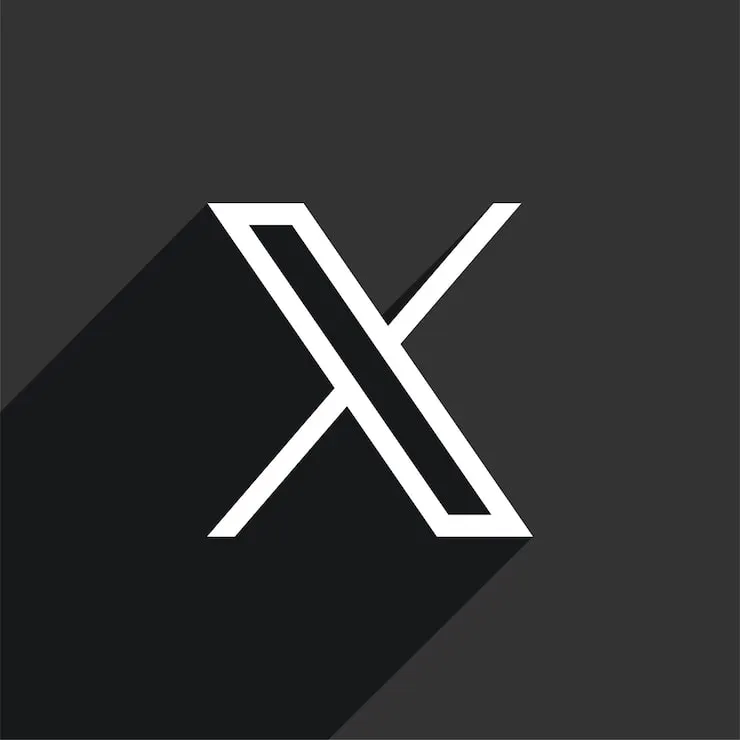
### Advanced NLP Pipeline — Classical ML + BERT Transformer

---

## 📋 Project Overview

This project builds an **end-to-end sentiment analysis system** capable 
of classifying airline customer tweets into three sentiment categories:
**Positive**, **Negative**, and **Neutral**.

It demonstrates two complete NLP approaches side by side — traditional 
Machine Learning with TF-IDF vectorization, and a state-of-the-art 
**BERT Transformer** fine-tuned on domain-specific data — allowing a 
direct, honest comparison between classical and deep learning methods.

---

## 🎯 Business Context

Airlines receive thousands of customer tweets daily. Manual review is 
impossible at scale. An automated sentiment classifier enables:

- **Real-time customer feedback monitoring**
- **Early detection of service failures** before they escalate
- **Routing negative tweets** to support teams automatically
- **Tracking sentiment trends** over time by airline, route, or issue type

---

## 📦 Dataset

| Property | Detail |
|---|---|
| **Source** | Twitter US Airline Sentiment — Kaggle |
| **Size** | ~14,000 tweets |
| **Period** | February 2015 |
| **Airlines** | United, Delta, American, Southwest, US Airways, Virgin America |
| **Target** | `airline_sentiment` → positive / negative / neutral |
| **Challenge** | Real messy text — slang, typos, @mentions, hashtags, URLs |

---

## ⚠️ Key Challenge — Class Imbalance

The dataset is heavily skewed toward negative sentiment — reflecting 
real-world behavior where unhappy customers tweet far more than 
satisfied ones. This imbalance must be handled carefully to avoid 
a model that simply predicts "negative" for everything.

---

## 🗺️ Pipeline

| Step | Description | Tools |
|---|---|---|
| 1 | Load & explore data | kagglehub, pandas |
| 2 | EDA — distributions, word clouds | matplotlib, wordcloud |
| 3 | Text cleaning & lemmatization | nltk, regex |
| 4 | Train/test split | sklearn |
| 5 | TF-IDF vectorization | TfidfVectorizer |
| 6 | Classical model comparison | LR, SVM, RF, XGBoost, NaiveBayes |
| 7 | Handle class imbalance | class_weight, SMOTE |
| 8 | Tune the winner | BayesSearchCV |
| 9 | Feature importance | Most influential words per sentiment |
| 10 | Error analysis | What does the model get wrong and why? |
| 11 | BERT fine-tuning | HuggingFace Transformers, PyTorch |
| 12 | Classical vs BERT comparison | Final scorecard |
| 13 | SHAP values | Model interpretability |
| 14 | End-to-end inference | Predict on raw new text |
| 15 | Export | joblib + HuggingFace save |
| 16 | Conclusion | Honest limitations & next steps |

---

## 🧰 Two Approaches Compared

### Approach 1 — Classical ML (TF-IDF + Sklearn)
Fast, interpretable, explainable. Treats text as a bag of words — 
word meaning and context are lost, but performance is surprisingly strong.

### Approach 2 — BERT Transformer (Deep Learning)
Slow to train but understands word meaning in context. "not good" and 
"good" are treated completely differently — a capability classical 
models fundamentally lack.

---

## 📐 Coding Standards

- All text cleaning applied **before** the split where safe
- Vectorization and modeling inside **pipelines** — no leakage
- Same `StratifiedKFold` CV strategy across **all** models
- Test

## 📊 Data Source

We load the Twitter US Airline Sentiment dataset directly from Kaggle 
using `kagglehub`. The dataset contains ~14,000 real customer tweets 
from February 2015 across 6 major US airlines.

> Source: [Twitter US Airline Sentiment dataset](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment)

#### 📥 Loading the Dataset

We read the located CSV into a pandas DataFrame — this is our raw, 
unprocessed dataset, straight from the Kaggle download.

In [92]:
%pip install pandas numpy matplotlib seaborn scikit-learn nltk jupyterlab transformers torch datasets wordcloud shap watermark imbalanced-learn xgboost kagglehub -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [124]:
# ============================================================
# 📦 DEPENDENCIES
# ============================================================

# ✅ Core
import os
import re
import warnings
import logging
import joblib
import numpy as np
import pandas as pd
import matplotlib as plt

warnings.filterwarnings('ignore', category=UserWarning)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ✅ Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from wordcloud import WordCloud
plt.style.use('dark_background')

# ✅ Text Processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet')
nltk.download('omw-1.4')

# ✅ Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# ✅ Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

# ✅ Pipeline
from sklearn.pipeline import Pipeline

# ✅ Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)

# ✅ Validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_val_predict
)

print("✅ All dependencies loaded!")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LarTI\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\LarTI\AppData\Roaming\nltk_data...


✅ All dependencies loaded!


In [94]:
# Load the watermark extension to log the environment state
%reload_ext watermark

# Display professional metadata tracking our data engineering stack (NO SPACES after commas)
%watermark -a "Maykon - Twitter US Airline Sentiment Analysis 🐦 (Didn't find a blue bird!) " -d -u -v -p pandas,numpy,matplotlib,seaborn,scikit-learn,nltk,jupyterlab,transformers,torch,datasets,wordcloud,shap,watermark,imbalanced-learn,xgboost,kagglehub

Author: Maykon - Twitter US Airline Sentiment Analysis 🐦 (Didn't find a blue bird!) 

Last updated: 2026-09-12

Python implementation: CPython
Python version       : 3.13.7
IPython version      : 9.17.1

pandas          : 3.0.5
numpy           : 2.5.3
matplotlib      : 3.11.1
seaborn         : 0.13.2
scikit-learn    : 1.9.0
nltk            : 3.10.3
jupyterlab      : 4.6.3
transformers    : 5.16.1
torch           : 2.14.0
datasets        : 5.0.1
wordcloud       : 1.9.6
shap            : 0.52.0
watermark       : 2.6.0
imbalanced-learn: 0.14.2
xgboost         : 3.4.1
kagglehub       : 1.0.2



> OBS: This project was built with assistance from Claude (Anthropic) for 
> code review, debugging, and explanation throughout the notebook.

In [95]:
# --- AUTOMATED KAGGLE INGESTION ---
# Download the latest version of dataset
path = kagglehub.dataset_download("crowdflower/twitter-airline-sentiment")
print("🚀 Path to dataset files:", path)

🚀 Path to dataset files: C:\Users\LarTI\.cache\kagglehub\datasets\crowdflower\twitter-airline-sentiment\versions\4


In [96]:
# --- LOCATING AND READING THE CSV ---
# List out all files inside the downloaded repository path to spot the target file
all_files = os.listdir(path)
print("📂 Files discovered in directory:", all_files)

# Filter out all CSV files dynamically
csv_files = [file for file in all_files if file.endswith('.csv')]

if len(csv_files) == 0:
    raise FileNotFoundError("❌ Critical Error: No CSV files found in the downloaded folder!")
else:
    # Grab the primary CSV file found
    csv_filename = csv_files[0]
    full_csv_path = os.path.join(path, csv_filename)
    print(f"🎯 Target CSV located: {csv_filename}")

📂 Files discovered in directory: ['database.sqlite', 'Tweets.csv']
🎯 Target CSV located: Tweets.csv


In [97]:
# Ingest the dataset into a pandas DataFrame
df = pd.read_csv(full_csv_path)
print(f"✅ Dataset successfully loaded! Named 'df', Shape: {df.shape[0]} rows, {df.shape[1]} columns.")

✅ Dataset successfully loaded! Named 'df', Shape: 14640 rows, 15 columns.


In [98]:
# Display the first 5 records to see our column properties and labels
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [99]:
df.shape # (columns, rows)
print("Number of columns:", df.shape[1])
print("Number of rows:", df.shape[0])

Number of columns: 15
Number of rows: 14640


In [100]:
df.sample(15) # Random 15 rows

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
3239,568574762433138690,neutral,1.0000,NaN,NaN,United,NaN,tdawghill,NaN,0,@united Bought a round trip to Chicago two day...,NaN,2015-02-19 16:56:01 -0800,San Francisco,NaN
8184,568631189856264192,positive,1.0000,NaN,NaN,Delta,NaN,BorjaAngoitia1,NaN,0,"@JetBlue Great Thank you, lets hope so! Could ...",NaN,2015-02-19 20:40:14 -0800,NaN,NaN
12114,570284660510433280,neutral,1.0000,NaN,NaN,American,NaN,sammy575,NaN,0,@AmericanAir what's the status of flight 1357 ...,NaN,2015-02-24 10:10:33 -0800,New York,Eastern Time (US & Canada)
948,569995706909503488,positive,1.0000,NaN,NaN,United,NaN,TuraOntheroad,NaN,0,@united Thank you!,NaN,2015-02-23 15:02:21 -0800,Brooklyn,Pacific Time (US & Canada)
1172,569906831352578049,negative,1.0000,Can't Tell,0.3442,United,NaN,JuanseMolano,NaN,0,@united and those three people were awesome wo...,NaN,2015-02-23 09:09:11 -0800,NaN,Quito
453,567893201719156736,positive,0.6559,NaN,NaN,Virgin America,NaN,KallysAlbertSr,NaN,0,@VirginAmerica That's classy.,NaN,2015-02-17 19:47:44 -0800,USA,NaN
7243,569836232999612417,positive,1.0000,NaN,NaN,Delta,NaN,globalwriter1,NaN,0,"@JetBlue Thanks JB. Actually, As a birder I lo...",NaN,2015-02-23 04:28:39 -0800,"40.41,-73.19",Eastern Time (US & Canada)
3871,568063784318832640,negative,1.0000,Late Flight,1.0000,United,NaN,jabbs7,NaN,0,@united UA6255 delayed out of #winnipeg becaus...,NaN,2015-02-18 07:05:34 -0800,Founder @catapultgrp @ilikeoi,Central Time (US & Canada)
5980,568448242804871168,negative,1.0000,Cancelled Flight,0.3370,Southwest,NaN,KTmBoyle,NaN,0,@SouthwestAir having trouble reFlight Booking ...,NaN,2015-02-19 08:33:16 -0800,Gone West,Eastern Time (US & Canada)
9951,569602817633222656,negative,1.0000,Lost Luggage,1.0000,US Airways,NaN,WarrickHoward,NaN,0,@USAirways Please can someone contact me regar...,NaN,2015-02-22 13:01:09 -0800,NaN,London


In [101]:
df.tail() #Displays the last 5 rows of the DataFrame df.

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)
14639,569587140490866689,neutral,0.6771,NaN,0.0000,American,NaN,daviddtwu,NaN,0,@AmericanAir we have 8 ppl so we need 2 know h...,NaN,2015-02-22 11:58:51 -0800,"dallas, TX",NaN


In [102]:
df.dtypes #Displays the data type of each column in the DataFrame.

tweet_id                          int64
airline_sentiment                   str
airline_sentiment_confidence    float64
negativereason                      str
negativereason_confidence       float64
airline                             str
airline_sentiment_gold              str
name                                str
negativereason_gold                 str
retweet_count                     int64
text                                str
tweet_coord                         str
tweet_created                       str
tweet_location                      str
user_timezone                       str
dtype: object

In [103]:
df.columns #Returns a list (Index object) containing the names of all columns in the DataFrame.

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')

### 🧹 Data Preprocessing & Hygiene

In [104]:
df.isna().sum() # Count missing values per column

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [105]:
print(f'The number of duplicate rows is: {df.duplicated().sum()}') # Count duplicate rows

The number of duplicate rows is: 36


In [106]:
df.drop_duplicates(inplace=True) # Remove duplicate rows from the DataFrame df.
print("Number of duplicate rows Now:", df.duplicated().sum()) # After dropping duplicates, check again to confirm that there are no duplicate rows remaining in the DataFrame df.

Number of duplicate rows Now: 0


In [107]:
# ============================================================
# 🧹 FEATURE SELECTION
# ============================================================

cols_to_drop = [
    'tweet_coord', 
    'tweet_created', 
    'tweet_location', 
    'user_timezone', 
    'tweet_id', 
    'airline_sentiment_gold', 
    'negativereason_gold', 
    'negativereason', 
    'negativereason_confidence', 
    'airline_sentiment_confidence',
    'name'
]

# Create a clean working copy without mutating raw data
dfc = df.drop(columns=cols_to_drop).copy()

print(f"✅ Remaining columns ({dfc.shape[1]}): {list(dfc.columns)}")
print(f"Missing values remaining:\n{dfc.isna().sum()}")

✅ Remaining columns (4): ['airline_sentiment', 'airline', 'retweet_count', 'text']
Missing values remaining:
airline_sentiment    0
airline              0
retweet_count        0
text                 0
dtype: int64


In [108]:
# ============================================================
# 🧹 COLUMN NAME SANITIZATION
# ============================================================
dfc.columns = (
    dfc.columns
    .str.lower()                                        # lowercase everything
    .str.strip()                                        # remove leading/trailing whitespace
    .str.replace(r"[^a-z0-9]+", "_", regex=True)       # replace anything not a letter/number with _
    .str.strip("_")                                     # remove leading/trailing underscores
)

print("✅ Columns sanitized:")
print(dfc.columns.tolist())

✅ Columns sanitized:
['airline_sentiment', 'airline', 'retweet_count', 'text']


### 📊 Exploratory Data Analysis (EDA)

Before any modeling we explore the dataset to understand:
- How imbalanced the sentiment classes are
- Which airlines generate the most complaints
- What words dominate each sentiment category
- How tweet length varies by sentiment

These findings directly shape our modeling decisions — especially
how we handle class imbalance.

In [109]:
# ============================================================
# 📋 BASIC INFO
# ============================================================

print("=" * 50)
print("📋 DATASET OVERVIEW")
print("=" * 50)
print(f"Total tweets     : {dfc.shape[0]:,}")
print(f"Total columns    : {dfc.shape[1]}")
print()
print("📊 Sentiment Distribution:")
print(dfc['airline_sentiment'].value_counts())
print()
print("📊 Sentiment % Distribution:")
print((dfc['airline_sentiment'].value_counts(normalize=True) * 100).round(1))

📋 DATASET OVERVIEW
Total tweets     : 14,604
Total columns    : 4

📊 Sentiment Distribution:
airline_sentiment
negative    9159
neutral     3091
positive    2354
Name: count, dtype: int64

📊 Sentiment % Distribution:
airline_sentiment
negative    62.7
neutral     21.2
positive    16.1
Name: proportion, dtype: float64


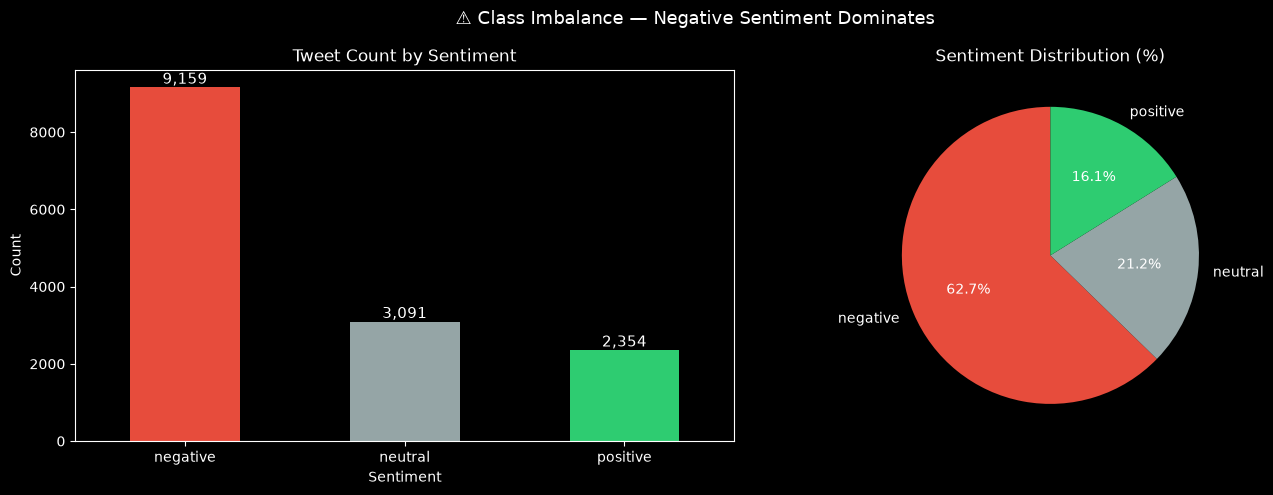

In [110]:
# ============================================================
# 📊 SENTIMENT DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#E74C3C', '#95A5A6', '#2ECC71']

dfc['airline_sentiment'].value_counts().plot(
    kind      = 'bar',
    ax        = axes[0],
    color     = colors,
    edgecolor = 'none'
)
axes[0].set_title('Tweet Count by Sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

for bar in axes[0].patches:
    axes[0].annotate(
        f'{int(bar.get_height()):,}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center', va='bottom', fontsize=11
    )

dfc['airline_sentiment'].value_counts().plot(
    kind       = 'pie',
    ax         = axes[1],
    colors     = colors,
    autopct    = '%1.1f%%',
    startangle = 90
)
axes[1].set_title('Sentiment Distribution (%)')
axes[1].set_ylabel('')

plt.suptitle('⚠️ Class Imbalance — Negative Sentiment Dominates', fontsize=13)
plt.tight_layout()
plt.show()

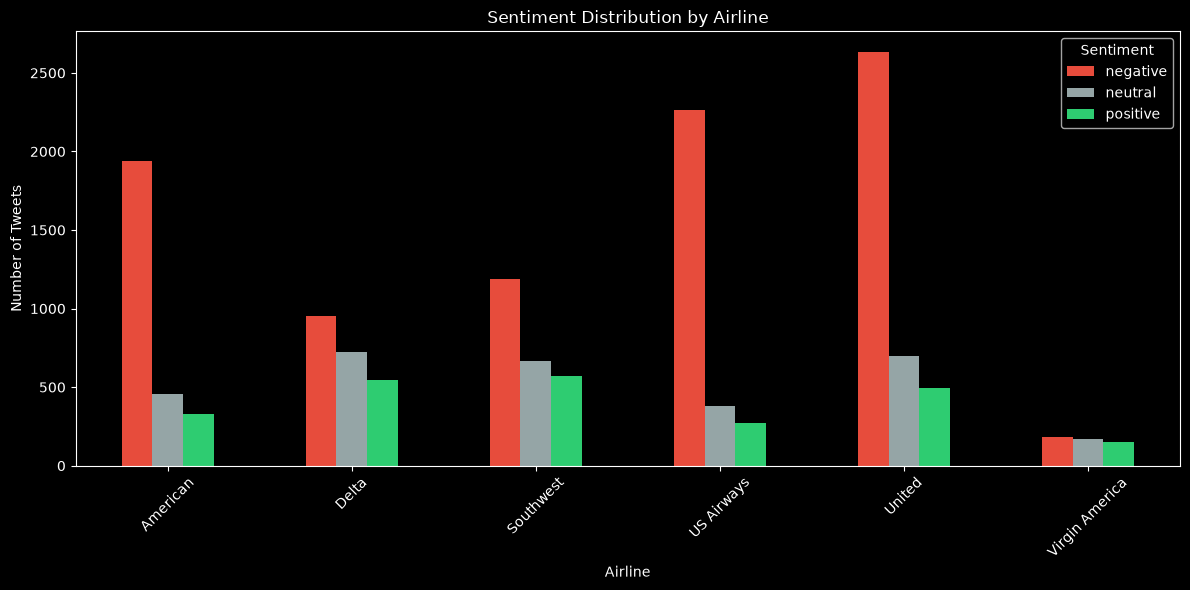


📊 Negative rate by airline (%):
airline
US Airways        77.7
American          71.3
United            68.9
Southwest         49.0
Delta             43.0
Virgin America    35.9
dtype: float64


In [111]:
# ============================================================
# ✈️ SENTIMENT BY AIRLINE
# ============================================================

airline_sentiment = dfc.groupby(
    ['airline', 'airline_sentiment']
).size().unstack().fillna(0)

airline_sentiment.plot(
    kind      = 'bar',
    figsize   = (12, 6),
    color     = colors,
    edgecolor = 'none'
)
plt.title('Sentiment Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Tweets')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n📊 Negative rate by airline (%):")
neg_rate = (
    dfc[dfc['airline_sentiment'] == 'negative']
    .groupby('airline').size() /
    dfc.groupby('airline').size() * 100
).round(1).sort_values(ascending=False)
print(neg_rate)

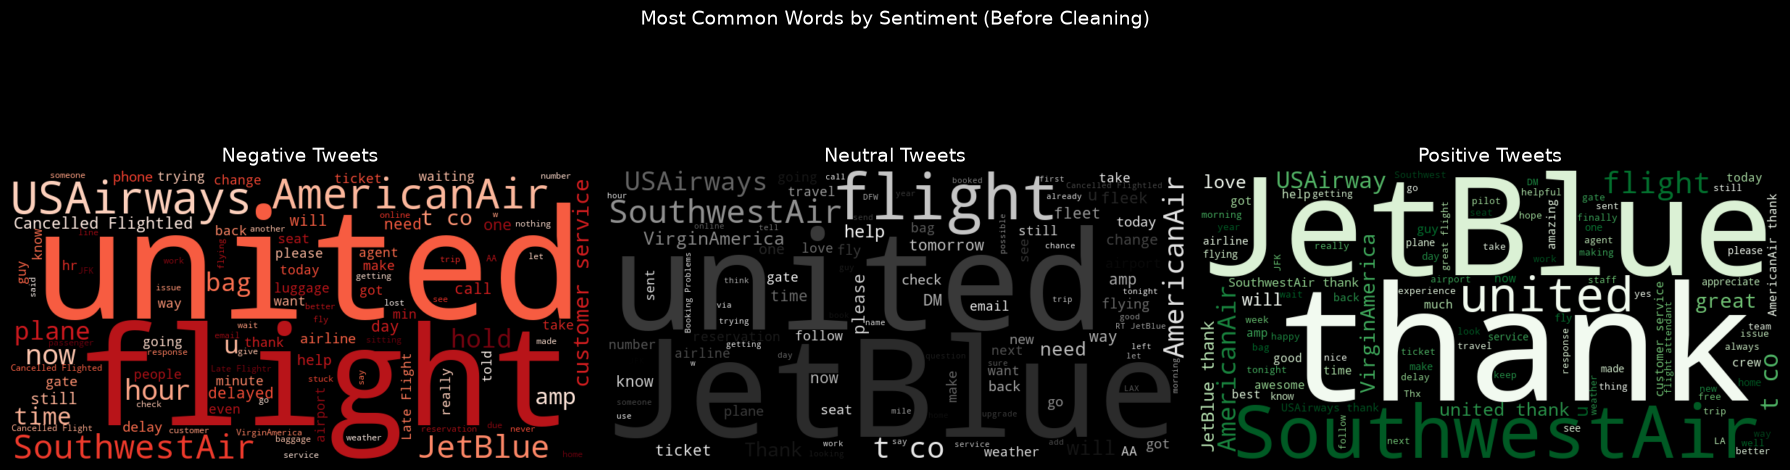

In [113]:
# ============================================================
# ☁️ WORD CLOUDS PER SENTIMENT
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentiments = {
    'negative': ('#E74C3C', 'Reds',   axes[0]),
    'neutral' : ('#95A5A6', 'Greys',  axes[1]),
    'positive': ('#2ECC71', 'Greens', axes[2])
}

for sentiment, (color, cmap, ax) in sentiments.items():
    text = ' '.join(
        dfc[dfc['airline_sentiment'] == sentiment]['text'].tolist()
    )
    wc = WordCloud(
        width            = 800,
        height           = 400,
        background_color = 'black',
        colormap         = cmap,
        max_words        = 100
    ).generate(text)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Tweets', fontsize=14)
    ax.axis('off')

plt.suptitle(
    'Most Common Words by Sentiment (Before Cleaning)',
    fontsize=14
)
plt.tight_layout()
plt.show()

📊 Retweet count by sentiment:
                    count  mean   std  min  25%  50%  75%   max
airline_sentiment                                              
negative           9159.0  0.09  0.79  0.0  0.0  0.0  0.0  44.0
neutral            3091.0  0.06  0.66  0.0  0.0  0.0  0.0  28.0
positive           2354.0  0.07  0.66  0.0  0.0  0.0  0.0  22.0



<Figure size 800x500 with 0 Axes>

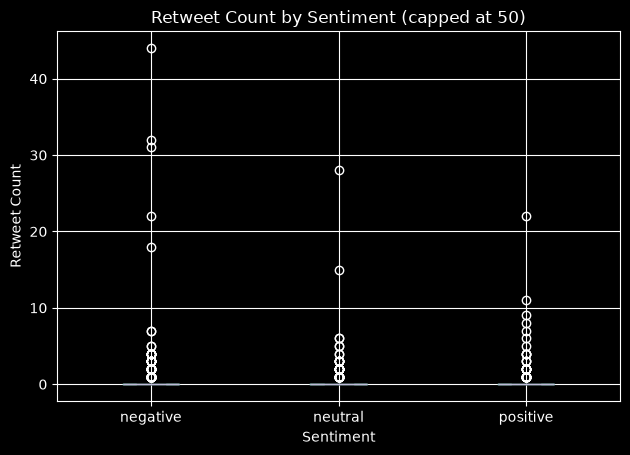

In [114]:
# ============================================================
# 🔁 RETWEET COUNT BY SENTIMENT
# ============================================================

print("📊 Retweet count by sentiment:")
print(dfc.groupby('airline_sentiment')['retweet_count'].describe().round(2))
print()

plt.figure(figsize=(8, 5))
dfc[dfc['retweet_count'] < 50].boxplot(
    column = 'retweet_count',
    by     = 'airline_sentiment'
)
plt.title('Retweet Count by Sentiment (capped at 50)')
plt.suptitle('')
plt.xlabel('Sentiment')
plt.ylabel('Retweet Count')
plt.tight_layout()
plt.show()

**Key EDA findings:**
- **Negative tweets dominate** (~63%) — severe class imbalance
  that must be handled during modeling
- **United Airlines** has the highest negative rate — most complaints
- **Negative tweets are slightly longer** — unhappy customers
  write more
- **Word clouds show noise** — @mentions, URLs, and airline names
  dominate before cleaning — this motivates our text cleaning pipeline
- **Retweet count is mostly 0** — viral tweets are rare exceptions

### 🧹 Text Cleaning Pipeline

Raw tweets are extremely noisy — full of @mentions, URLs, hashtags,
punctuation, numbers, and stopwords that add no sentiment signal.

We apply a full NLP cleaning pipeline to every tweet:

| Step | What it removes | Example |
|---|---|---|
| Lowercase | Inconsistent casing | `BAD` → `bad` |
| Remove @mentions | Usernames | `@united` → `` |
| Remove URLs | Links | `http://t.co/xyz` → `` |
| Remove hashtags | Hash symbol | `#worst` → `worst` |
| Remove punctuation | Special chars | `bad!!` → `bad` |
| Remove numbers | Digits | `flight123` → `flight` |
| Remove stopwords | Common words | `is`, `the`, `so` → `` |
| Lemmatization | Word root form | `flying` → `fly` |

> ⚠️ Text cleaning is applied to the **full dataset** before the
> split — because it's purely structural transformation with no
> statistical learning involved. No leakage risk here.

In [125]:
# ============================================================
# 🧹 TEXT CLEANING PIPELINE
# ============================================================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep negation words — they carry sentiment signal
negation_words = {'no', 'not', 'nor', 'neither', 'never', 'nobody',
                  'nothing', 'nowhere', 'hardly', 'barely', 'scarcely'}
stop_words = stop_words - negation_words

def clean_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 4. Remove hashtag symbol but keep the word
    text = re.sub(r'#', '', text)

    # 5. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 6. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 7. Tokenize
    tokens = word_tokenize(text)

    # 8. Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return ' '.join(tokens)

print("✅ Text cleaning function defined!")
print()
print("Example:")
sample = "@united why is your service so bad!! 😤 http://t.co/xyz #worst"
print(f"Before: {sample}")
print(f"After : {clean_text(sample)}")

✅ Text cleaning function defined!

Example:
Before: @united why is your service so bad!! 😤 http://t.co/xyz #worst
After : service bad worst
